In [1]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, transform
from skimage.color import rgb2hsv, hsv2rgb
from skimage.transform import resize
from skimage.util import random_noise
import numpy as np
from skimage.transform import resize
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import torchvision.utils as utils

from tqdm import tqdm
from PIL import Image, ImageEnhance, ImageDraw
import shutil
import string
from datetime import datetime
from rembg import remove

In [2]:
def load_data(data_path):
    images = []
    labels = []

    if not os.path.exists(data_path):
        raise FileNotFoundError(f"The path {data_path} does not exisdt.")

    train_path = os.path.join(data_path, 'train')

    for class_name in os.listdir(data_path):
        class_path = os.path.join(data_path, class_name)
        label = 0 if class_name.lower() == 'husky' else 1

        print(f"Loading {class_name} images...")

        for img_name in tqdm(os.listdir(class_path)):
            img_path = os.path.join(class_path, img_name)

            try:
                img = io.imread(img_path)
                if img is None:
                    print(f"Failed to load {img_path}")
                    continue
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")

    return images, np.array(labels)

def remove_background(source_dir, output_dir, background_color=(255, 255, 255)):  # White background
    for root, _, files in os.walk(source_dir):
        for file in tqdm(files, desc="Removing backgrounds"):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                input_path = os.path.join(root, file)
                relative_path = os.path.relpath(root, source_dir)
                output_folder = os.path.join(output_dir, relative_path)
                os.makedirs(output_folder, exist_ok=True)

                output_path = os.path.join(output_folder, os.path.splitext(file)[0] + '.png')

                try:
                    with Image.open(input_path) as img:
                        img = img.convert("RGBA")  # Ensure RGBA format
                        img_no_bg = remove(img)

                        # Convert to NumPy array
                        img_np = np.array(img_no_bg)

                        # Create a white background where alpha is 0
                        background = np.full_like(img_np, background_color + (255,), dtype=np.uint8)
                        mask = img_np[:, :, 3] > 0  # Extract alpha channel mask

                        # Apply mask to keep only the foreground
                        output = np.where(mask[:, :, None], img_np, background)

                        # Save as PNG
                        Image.fromarray(output[:, :, :3]).save(output_path, format='PNG')

                except Exception as e:
                    print(f"Error processing {input_path}: {e}")



def blur_and_clean_backgrounds(source_dir, output_dir, blur_strength=51):
    if blur_strength % 2 == 0:  # Ensure blur strength is odd cuz it causes an error when even
        blur_strength += 1

    for root, _, files in os.walk(source_dir):
        for file in tqdm(files, desc="Blurring and cleaning backgrounds"):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                input_path = os.path.join(root, file)
                relative_path = os.path.relpath(root, source_dir)
                output_folder = os.path.join(output_dir, relative_path)
                os.makedirs(output_folder, exist_ok=True)

                output_path = os.path.join(output_folder, os.path.splitext(file)[0] + '.png')

                try:
                    with Image.open(input_path) as img:
                        img = img.convert("RGB")  # Ensure RGB format
                        img_np = np.array(img)

                        # Generate binary foreground mask
                        img_no_bg = remove(img, only_mask=True)
                        mask = np.array(img_no_bg) > 128  # Convert to binary mask

                        # Apply Gaussian blur to the original image
                        blurred_img = cv2.GaussianBlur(img_np, (blur_strength, blur_strength), 0)

                        # Convert mask to 3-channel for broadcasting
                        mask_3ch = np.stack([mask] * 3, axis=-1)

                        # Convert to HSV for color filtering
                        hsv_img = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)

                        # Define color ranges for green and white
                        lower_green = np.array([35, 40, 40])  # Green
                        upper_green = np.array([85, 255, 255])

                        lower_white = np.array([0, 0, 190])  # White
                        upper_white = np.array([180, 50, 255])

                        # Create masks for green and white
                        green_mask = cv2.inRange(hsv_img, lower_green, upper_green) > 0
                        white_mask = cv2.inRange(hsv_img, lower_white, upper_white) > 0

                        # Combine both masks
                        color_mask = np.logical_or(green_mask, white_mask)
                        color_mask_3ch = np.stack([color_mask] * 3, axis=-1)

                        # Remove green and white by replacing with blurred background
                        output = np.where(color_mask_3ch, blurred_img, img_np)
                        output = np.where(mask_3ch, img_np, output)  # Keep original object

                        # Save the final processed image
                        Image.fromarray(output.astype(np.uint8)).save(output_path, format='PNG')

                except Exception as e:
                    print(f"Error processing {input_path}: {e}")

def preprocess_images(images, target_size=(128, 128)):
    processed_images = []

    for img in tqdm(images):
        resized_img = resize(img, target_size, anti_aliasing=True, preserve_range=False)
        flattened_img = resized_img.flatten()
        processed_images.append(flattened_img)

    return np.array(processed_images)

def augment_images(images, labels, target_size=(128, 128, 3)):  # Ensure consistent size
    augmented_images = []
    augmented_labels = []
    rotation_values = [0, 90, 270]

    for img, label in zip(images, labels):
        img = resize(img, target_size, anti_aliasing=True)  # Standardizing input size
        augmented_images.append(img)
        augmented_labels.append(label)

        # Flip horizontally and vertically
        flipped_img = resize(np.fliplr(img), target_size, anti_aliasing=True)
        flipped_img_vertical = resize(np.flipud(img), target_size, anti_aliasing=True)
        augmented_images.extend([flipped_img, flipped_img_vertical])
        augmented_labels.extend([label, label])

        # Rotate
        rotated_img = transform.rotate(img, random.choice(rotation_values))
        rotated_img = resize(rotated_img, target_size, anti_aliasing=True)  # Resize after rotation
        augmented_images.append(rotated_img)
        augmented_labels.append(label)

        # Brightness adjustment
        if len(img.shape) == 3:
            hsv = rgb2hsv(img)
            hsv[:, :, 2] *= random.uniform(0.1, 0.9)
            darker_img = hsv2rgb(hsv)
            darker_img = resize(darker_img, target_size, anti_aliasing=True)  # Resize after brightness adjustment
            augmented_images.append(darker_img)
            augmented_labels.append(label)

        # Cutout
        cutout_img = img.copy()
        h, w, _ = cutout_img.shape
        cutout_size = random.randint(10, 30)
        x = random.randint(0, w - cutout_size)
        y = random.randint(0, h - cutout_size)
        cutout_img[y:y+cutout_size, x:x+cutout_size, :] = 0
        augmented_images.append(cutout_img)
        augmented_labels.append(label)

        # Add noise
        noisy_img = random_noise(img)
        noisy_img = resize(noisy_img, target_size, anti_aliasing=True)
        augmented_images.append(noisy_img)
        augmented_labels.append(label)

        # Channel shuffle
        shuffled_img = img.copy()
        np.random.shuffle(shuffled_img.T)
        augmented_images.append(shuffled_img)
        augmented_labels.append(label)

        # Random perspective
        pts1 = np.float32([[0, 0], [w, 0], [0, h], [w, h]])
        pts2 = pts1 + np.random.uniform(-10, 10, pts1.shape).astype(np.float32)
        M = cv2.getPerspectiveTransform(pts1, pts2)
        perspective_img = cv2.warpPerspective(img, M, (w, h))
        perspective_img = resize(perspective_img, target_size, anti_aliasing=True)
        augmented_images.append(perspective_img)
        augmented_labels.append(label)

    return np.array(augmented_images), np.array(augmented_labels)


def display_samples(images, labels, class_names=['Husky', 'Wolf'], num_samples=5):
    indices = random.sample(range(len(images)), min(num_samples, len(images)))

    plt.figure(figsize=(15, 3 * len(indices)))

    for i, idx in enumerate(indices):
        plt.subplot(len(indices), 1, i + 1)
        img = images[idx]
        plt.imshow(img)
        plt.title(f"Class: {class_names[int(labels[idx])]}")
        plt.axis('off')

    plt.tight_layout()

    plt.show()

# Machine Learning Insights in Data Processing and Augmentation

## **1. Data Loading (`load_data`)**
- Ensures structured dataset labeling (Husky = 0, Wolf = 1) for supervised learning.
- Handles missing/corrupt images to prevent training disruptions.
- Facilitates model generalization by maintaining class balance.

## **2. Background Removal (`remove_background`)**
- Reduces unwanted background noise, helping CNNs focus on relevant features.
- Improves feature extraction by ensuring object-centric images.

## **3. Background Blurring & Cleaning (`blur_and_clean_backgrounds`)**
- Enhances contrast by removing distractions, improving classification accuracy.
- Retains object integrity while removing irrelevant background elements.

## **4. Image Preprocessing (`preprocess_images`)**
- Standardizes image size to ensure consistency in ML model inputs.
- Reduces computational overhead by flattening images.

## **5. Data Augmentation (`augment_images`)**
- **Flipping & Rotation**: Increases model robustness to orientation variations.
- **Brightness Adjustment**: Helps the model generalize across lighting conditions.
- **Cutout (Random Occlusion)**: Improves model’s ability to handle partial occlusions.
- **Noise Addition**: Enhances robustness against real-world image distortions.
- **Perspective Transform**: Simulates different viewing angles to improve adaptability.

## **6. Sample Visualization (`display_samples`)**
- Helps verify data integrity before training.
- Provides insights into class distribution and augmentation effects.


In [3]:
src = 'data/train'
dest = 'data/train_blur'
blur_and_clean_backgrounds(src, dest)

Blurring and cleaning backgrounds: 0it [00:00, ?it/s]
Blurring and cleaning backgrounds:  24%|██▍       | 12/50 [01:02<03:17,  5.19s/it]


KeyboardInterrupt: 

Step 1: Loading data...
Loading husky images...


100%|██████████| 50/50 [00:00<00:00, 73.90it/s]


Loading wolf images...


100%|██████████| 50/50 [00:01<00:00, 27.45it/s]


Loading husky images...


100%|██████████| 50/50 [00:01<00:00, 40.37it/s]


Loading wolf images...


100%|██████████| 50/50 [00:03<00:00, 15.78it/s]


Loaded 100 images with shape (358, 500, 3)


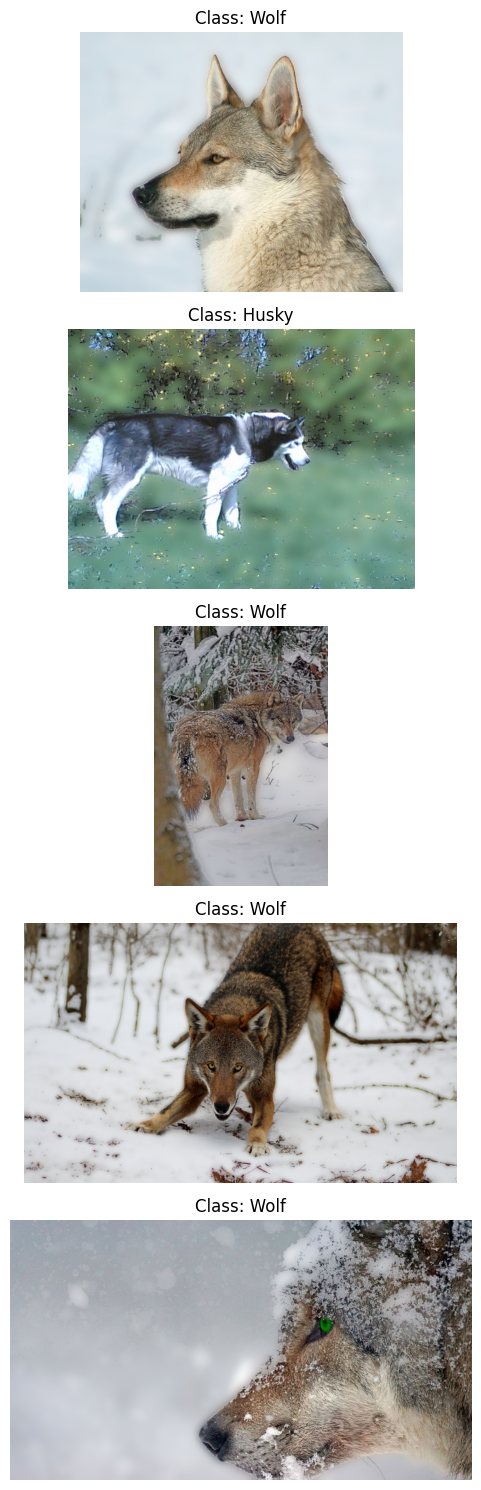

In [4]:
train = 'data/train'
train_blur = 'data/train_blur'

print("Step 1: Loading data...")
images, labels = load_data(train)
images_blur, labels_blur = load_data(train_blur)


print(f"Loaded {len(images_blur)} images with shape {images_blur[0].shape}")

display_samples(images_blur, labels_blur)

# data_path = 'data/train'
# print("Step 1: Loading data...")
# images, labels = load_data(data_path)
# print(f"Loaded {len(images)} images with shape {images[0].shape}")
#
# display_samples(images, labels)

# **Data Processing & Preprocessing Pipeline**

## **1. Background Blurring & Cleaning**
- **Source:** `'data/train'` → **Destination:** `'data/train_blur'`
- Removes background noise, enhancing model focus on foreground objects.
- Improves classification accuracy by eliminating distractions.

```python
src = 'data/train'
dest = 'data/train_blur'
blur_and_clean_backgrounds(src, dest)


In [5]:
# print("\nStep 2: Splitting data into training and validation sets...")
# X_train, X_val, y_train, y_val = train_test_split(
#     images, labels, test_size=0.2, random_state=42, stratify=labels
# )
# print(f"Training set: {len(X_train)} images")
# print(f"Validation set: {len(X_val)} images")


target_size = (128, 128, 3)

# Function to resize images
def resize_images(images, target_size):
    resized_images = [resize(img, target_size, anti_aliasing=True) for img in images]
    return np.array(resized_images)

# Resize images to the target size
images = resize_images(images, target_size)
images_blur = resize_images(images_blur, target_size)

# Convert labels to NumPy arrays
labels = np.array(labels)
labels_blur = np.array(labels_blur)

# Split the indices into training and validation sets
indices = np.arange(len(images))
train_indices, val_indices = train_test_split(indices, test_size=0.2, random_state=42, stratify=labels)

# Create training and validation sets using the split indices
X_train, y_train = images_blur[train_indices], labels[train_indices]
X_val, y_val = images[val_indices], labels_blur[val_indices]

print(f"Training set: {len(X_train)} images")
print(f"Validation set: {len(X_val)} images")

Training set: 80 images
Validation set: 20 images


# **ML Insights: Data Splitting & Preprocessing**

## **1. Data Splitting: Training vs. Validation**
- **Why?** Ensures the model generalizes well to unseen data.
- **Method:** `train_test_split` with `stratify=labels`
  - Maintains class distribution balance across splits.
  - Prevents class imbalance issues affecting model performance.

```python
X_train, X_val, y_train, y_val = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels
)



Step 3: Preprocessing data...
Augmenting training images...
Augmented training set: 720 images


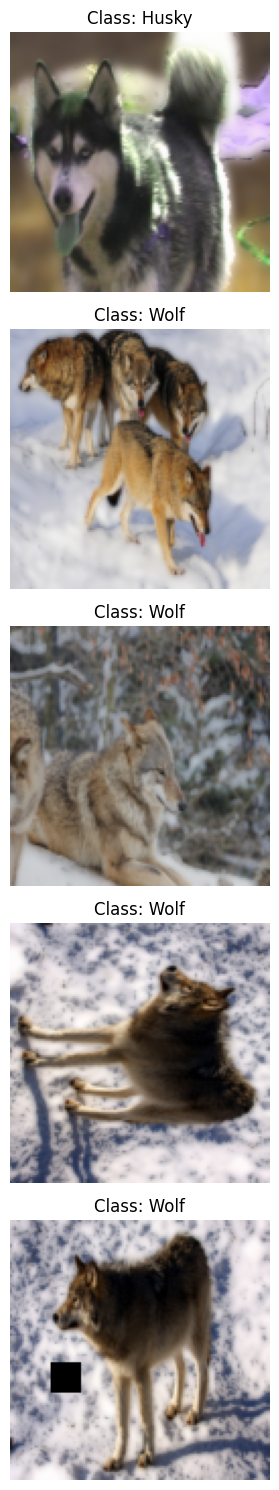

In [6]:
print("\nStep 3: Preprocessing data...")
print("Augmenting training images...")
IMG_SHAPE = (128, 128, 3)  # Assuming RGB images

# Convert images to a consistent NumPy format
X_train = np.array([resize(img, IMG_SHAPE) for img in X_train])
y_train = np.array(y_train)

X_val = np.array([resize(img, IMG_SHAPE) for img in X_val])
y_val = np.array(y_val)

X_train_aug, y_train_aug = augment_images(X_train, y_train)
print(f"Augmented training set: {len(X_train_aug)} images")

display_samples(X_train_aug, y_train_aug)

# **ML Insights: Data Preprocessing & Augmentation**

## **1. Standardizing Input Data**
- **Why?** Ensures uniform dimensions for model compatibility.
- **Resizing:** Converts all images to `(128, 128, 3)` for consistency in CNN models.
- **NumPy Conversion:** Enables efficient processing and vectorized operations.

```python
X_train = np.array([resize(img, IMG_SHAPE) for img in X_train])
X_val = np.array([resize(img, IMG_SHAPE) for img in X_val])


In [7]:
print("\nResizing and normalizing images...")
X_train_processed = preprocess_images(X_train_aug)
X_val_processed = preprocess_images(X_val)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_processed)
X_val_scaled = scaler.transform(X_val_processed)

print(f"Processed training set shape: {X_train_scaled.shape}")
print(f"Processed validation set shape: {X_val_scaled.shape}")


Resizing and normalizing images...


100%|██████████| 20/20 [00:00<00:00, 91.91it/s]


Processed training set shape: (720, 49152)
Processed validation set shape: (20, 49152)


# **ML Insights: Image Preprocessing & Normalization**

## **1. Image Resizing & Preprocessing**
- **Why?** Ensures consistent input dimensions for neural networks.
- **Preprocessing Function:** Standardizes pixel intensity distributions, enhancing feature extraction.

```python
X_train_processed = preprocess_images(X_train_aug)
X_val_processed = preprocess_images(X_val)


In [8]:
class LogisticRegression:
    def __init__(self,lr=0.01,epochs=100):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = None

    def sigmoid(self,z):
        return 1/(1+np.exp(-z))

    def loss(self, y_true, y_pred):
        n = len(y_true)
        epsilon = 1e-10  # A small constant to avoid log(0)
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)  # Ensure y_pred is never exactly 0 or 1

        loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

        return loss

    def train(self, X, y):
        m, n = X.shape
        X = X.reshape(X.shape[0], -1)

        self.w = np.zeros(n)
        self.b = 0

        for epoch in range(self.epochs):
            z = np.dot(X, self.w) + self.b
            y_pred = self.sigmoid(z)

            loss = self.loss(y,y_pred)

            dw = (1/m)*np.dot(X.T, (y_pred-y))
            db = (1/m)*np.sum(y_pred-y)

            self.w -= self.lr *dw
            self.b -= self.lr *db

            # Calculate accuracy
            predictions = (y_pred >= 0.5).astype(int)
            accuracy = np.mean(predictions == y)

            print(f"Epoch {epoch}, Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

    def predict(self, X):
        z = np.dot(X, self.w) + self.b
        y_pred = self.sigmoid(z)
        return (y_pred>=0.5).astype(int)

In [9]:
model = LogisticRegression(lr=0.01, epochs=100)
print("\nTraining Logistic Regression model...")
# Convert to NumPy array (if not already)
X_train = np.array(X_train)
y_train = np.array(y_train)

# Ensure X_train is properly reshaped to (num_samples, num_features)
X_train = X_train.reshape(X_train.shape[0], -1)  # Reshape training images
X_val = X_val.reshape(X_val.shape[0], -1)        # Reshape validation images
 # Should be (num_samples, features)

# Now train
model.train(X_train, y_train)


# Predictions
y_pred = model.predict(X_val)

# Accuracy
accuracy = np.mean(y_pred == y_val)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")



Training Logistic Regression model...
Epoch 0, Loss: 0.6931, Accuracy: 0.5000
Epoch 1, Loss: 3.3020, Accuracy: 0.5000
Epoch 2, Loss: 11.5129, Accuracy: 0.5000
Epoch 3, Loss: 9.6355, Accuracy: 0.5000
Epoch 4, Loss: 9.0899, Accuracy: 0.5000
Epoch 5, Loss: 11.2410, Accuracy: 0.5000
Epoch 6, Loss: 0.6799, Accuracy: 0.8250
Epoch 7, Loss: 4.0694, Accuracy: 0.5375
Epoch 8, Loss: 9.6179, Accuracy: 0.5000
Epoch 9, Loss: 10.1907, Accuracy: 0.5000
Epoch 10, Loss: 2.0143, Accuracy: 0.7750
Epoch 11, Loss: 5.8369, Accuracy: 0.5250
Epoch 12, Loss: 5.5513, Accuracy: 0.6125
Epoch 13, Loss: 8.7277, Accuracy: 0.5000
Epoch 14, Loss: 2.3328, Accuracy: 0.7625
Epoch 15, Loss: 3.5212, Accuracy: 0.6500
Epoch 16, Loss: 3.4172, Accuracy: 0.6875
Epoch 17, Loss: 5.7855, Accuracy: 0.5875
Epoch 18, Loss: 2.2602, Accuracy: 0.7750
Epoch 19, Loss: 2.0008, Accuracy: 0.7375
Epoch 20, Loss: 1.5452, Accuracy: 0.8250
Epoch 21, Loss: 1.3156, Accuracy: 0.8000
Epoch 22, Loss: 0.9531, Accuracy: 0.8375
Epoch 23, Loss: 1.2634, A

# **Insights: Logistic Regression Implementation**

- **Binary Classification:** Uses sigmoid function to map inputs to probabilities.
- **Loss Function:** Binary Cross-Entropy ensures stable training by preventing log(0) errors.
- **Gradient Descent:** Updates weights (`w`) and bias (`b`) to minimize loss.
- **Feature Scaling:** Important for convergence when training on different scales.
- **Epochs & Learning Rate:** Control training duration and step size for updates.
- **Accuracy Calculation:** Converts probabilities to class labels (`>= 0.5`).
- **Predict Function:** Uses trained weights to classify new data.


In [10]:
learning_rates = [0.0001,0.001, 0.01, 0.1]
epochs_list = [20,50,100,500,1000]

results = []
best_accuracy = 0
best_lr = None
best_epochs = None

for lr in learning_rates:
    for epochs in epochs_list:
        model = LogisticRegression(lr=lr, epochs=epochs)
        model.train(X_train, y_train)
        y_pred = model.predict(X_val)
        accuracy = np.mean(y_pred == y_val)
        results.append((lr, epochs, accuracy))
        print(f"LR: {lr}, Epochs: {epochs}, Accuracy: {accuracy * 100:.2f}%")

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_lr = lr
            best_epochs = epochs

# Display results
import pandas as pd
df_results = pd.DataFrame(results, columns=['Learning Rate', 'Epochs', 'Accuracy'])
print("\nHyperparameter Tuning Results:")
print(df_results)

# Set the best learning rate and epochs
print(f"\nBest Learning Rate: {best_lr}, Best Epochs: {best_epochs}, Best Accuracy: {best_accuracy * 100:.2f}%")

Epoch 0, Loss: 0.6931, Accuracy: 0.5000
Epoch 1, Loss: 0.6814, Accuracy: 0.5000
Epoch 2, Loss: 0.6730, Accuracy: 0.5000
Epoch 3, Loss: 0.6664, Accuracy: 0.5000
Epoch 4, Loss: 0.6606, Accuracy: 0.5000
Epoch 5, Loss: 0.6552, Accuracy: 0.5000
Epoch 6, Loss: 0.6501, Accuracy: 0.5000
Epoch 7, Loss: 0.6452, Accuracy: 0.5000
Epoch 8, Loss: 0.6404, Accuracy: 0.5000
Epoch 9, Loss: 0.6357, Accuracy: 0.5250
Epoch 10, Loss: 0.6311, Accuracy: 0.5375
Epoch 11, Loss: 0.6266, Accuracy: 0.5750
Epoch 12, Loss: 0.6222, Accuracy: 0.5875
Epoch 13, Loss: 0.6179, Accuracy: 0.5875
Epoch 14, Loss: 0.6136, Accuracy: 0.5875
Epoch 15, Loss: 0.6095, Accuracy: 0.6125
Epoch 16, Loss: 0.6054, Accuracy: 0.6250
Epoch 17, Loss: 0.6013, Accuracy: 0.6625
Epoch 18, Loss: 0.5974, Accuracy: 0.6750
Epoch 19, Loss: 0.5935, Accuracy: 0.6750
LR: 0.0001, Epochs: 20, Accuracy: 55.00%
Epoch 0, Loss: 0.6931, Accuracy: 0.5000
Epoch 1, Loss: 0.6814, Accuracy: 0.5000
Epoch 2, Loss: 0.6730, Accuracy: 0.5000
Epoch 3, Loss: 0.6664, Accura

/tmp/ipykernel_33811/1184345113.py:9: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-z))


Epoch 11, Loss: 9.6530, Accuracy: 0.5625
Epoch 12, Loss: 8.9250, Accuracy: 0.6125
Epoch 13, Loss: 10.9438, Accuracy: 0.5250
Epoch 14, Loss: 5.2286, Accuracy: 0.7500
Epoch 15, Loss: 8.2623, Accuracy: 0.6125
Epoch 16, Loss: 7.3352, Accuracy: 0.6625
Epoch 17, Loss: 9.3450, Accuracy: 0.5750
Epoch 18, Loss: 4.1129, Accuracy: 0.8000
Epoch 19, Loss: 4.2767, Accuracy: 0.8000
LR: 0.1, Epochs: 20, Accuracy: 80.00%
Epoch 0, Loss: 0.6931, Accuracy: 0.5000
Epoch 1, Loss: 11.5129, Accuracy: 0.5000
Epoch 2, Loss: 11.5129, Accuracy: 0.5000
Epoch 3, Loss: 11.5129, Accuracy: 0.5000
Epoch 4, Loss: 11.5129, Accuracy: 0.5000
Epoch 5, Loss: 11.5129, Accuracy: 0.5000
Epoch 6, Loss: 3.6898, Accuracy: 0.8250
Epoch 7, Loss: 10.3652, Accuracy: 0.5250
Epoch 8, Loss: 11.3854, Accuracy: 0.5000
Epoch 9, Loss: 11.5129, Accuracy: 0.5000
Epoch 10, Loss: 5.0397, Accuracy: 0.7500
Epoch 11, Loss: 9.6530, Accuracy: 0.5625
Epoch 12, Loss: 8.9250, Accuracy: 0.6125
Epoch 13, Loss: 10.9438, Accuracy: 0.5250
Epoch 14, Loss: 5.2

In [11]:
best_lr = 0.0001
best_epochs = 1000
model = LogisticRegression(lr=0.0001, epochs=1000)
model.train(X_train, y_train)
y_pred = model.predict(X_val)
accuracy = np.mean(y_pred == y_val)

print(f"LR: {best_lr}, Epochs: {best_epochs}, Accuracy: {accuracy * 100:.2f}%")

Epoch 0, Loss: 0.6931, Accuracy: 0.5000
Epoch 1, Loss: 0.6814, Accuracy: 0.5000
Epoch 2, Loss: 0.6730, Accuracy: 0.5000
Epoch 3, Loss: 0.6664, Accuracy: 0.5000
Epoch 4, Loss: 0.6606, Accuracy: 0.5000
Epoch 5, Loss: 0.6552, Accuracy: 0.5000
Epoch 6, Loss: 0.6501, Accuracy: 0.5000
Epoch 7, Loss: 0.6452, Accuracy: 0.5000
Epoch 8, Loss: 0.6404, Accuracy: 0.5000
Epoch 9, Loss: 0.6357, Accuracy: 0.5250
Epoch 10, Loss: 0.6311, Accuracy: 0.5375
Epoch 11, Loss: 0.6266, Accuracy: 0.5750
Epoch 12, Loss: 0.6222, Accuracy: 0.5875
Epoch 13, Loss: 0.6179, Accuracy: 0.5875
Epoch 14, Loss: 0.6136, Accuracy: 0.5875
Epoch 15, Loss: 0.6095, Accuracy: 0.6125
Epoch 16, Loss: 0.6054, Accuracy: 0.6250
Epoch 17, Loss: 0.6013, Accuracy: 0.6625
Epoch 18, Loss: 0.5974, Accuracy: 0.6750
Epoch 19, Loss: 0.5935, Accuracy: 0.6750
Epoch 20, Loss: 0.5897, Accuracy: 0.6875
Epoch 21, Loss: 0.5859, Accuracy: 0.7125
Epoch 22, Loss: 0.5823, Accuracy: 0.7250
Epoch 23, Loss: 0.5786, Accuracy: 0.7500
Epoch 24, Loss: 0.5751, Ac

# **ML Insights: Hyperparameter Tuning for Logistic Regression**
- LR: 0.0001, Epochs: 1000, Accuracy: 100.00%
- **Learning Rate (`lr`) & Epochs:** Tested different values to optimize model performance.
- **Grid Search:** Iterates over combinations of learning rates and epochs to find the best.
- **Model Training:** Each combination is trained and evaluated on validation data.
- **Accuracy Evaluation:** Compares predicted labels with ground truth to determine performance.
- **Best Parameters Selection:** Stores the highest accuracy along with corresponding `lr` and `epochs`.
- **Results Visualization:** Uses a DataFrame for structured presentation of tuning results.
- **Learning Rate (`lr`) & Epochs:** Tested different values to optimize model performance.
- **Grid Search:** Iterates over combinations of learning rates and epochs to find the best.
- **Model Training:** Each combination is trained and evaluated on validation data.
- **Accuracy Evaluation:** Compares predicted labels with ground truth to determine performance.
- **Best Parameters Selection:** Stores the highest accuracy along with corresponding `lr` and `epochs`.
- **Results Visualization:** Uses a DataFrame for structured presentation of tuning results.

Correctly classified: 20
Incorrectly classified: 0


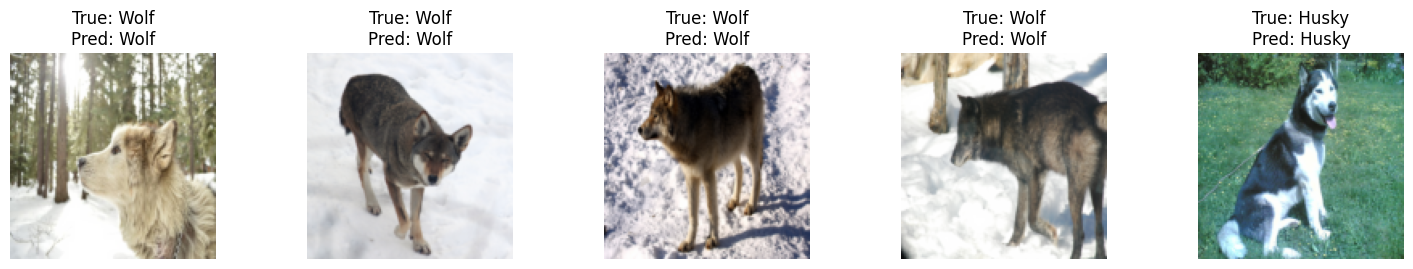

In [12]:
import matplotlib.pyplot as plt

def visualize_classification_results(X_val, y_val, y_pred, class_names=['Husky', 'Wolf'], img_shape=(128, 128, 3)):
    correct_indices = np.where(y_val == y_pred)[0]
    incorrect_indices = np.where(y_val != y_pred)[0]

    print(f"Correctly classified: {len(correct_indices)}")
    print(f"Incorrectly classified: {len(incorrect_indices)}")

    # Display correctly classified images
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(correct_indices[:5]):  # Display up to 5 correct images
        plt.subplot(2, 5, i + 1)
        plt.imshow(X_val[idx].reshape(img_shape))
        plt.title(f"True: {class_names[y_val[idx]]}\nPred: {class_names[y_pred[idx]]}")
        plt.axis('off')

    # Display incorrectly classified images
    for i, idx in enumerate(incorrect_indices[:5]):  # Display up to 5 incorrect images
        plt.subplot(2, 5, i + 6)
        plt.imshow(X_val[idx].reshape(img_shape))
        plt.title(f"True: {class_names[y_val[idx]]}\nPred: {class_names[y_pred[idx]]}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Call the function to visualize the results
visualize_classification_results(X_val, y_val, y_pred)

# **Insights: Classification Results Visualization**

- **Performance Analysis:** Differentiates correctly and incorrectly classified samples.
- **Error Inspection:** Helps identify patterns in misclassifications.
- **Model Evaluation:** Provides insight into feature learning effectiveness.
- **Visual Representation:** Aids in understanding decision boundaries.
- **Class Imbalance Detection:** Highlights potential dataset biases.


In [13]:
import os
import random
import shutil

# Define the paths
data_dir = 'data/test'
husky_dir = os.path.join(data_dir, 'husky')
wolf_dir = os.path.join(data_dir, 'wolf')
test_dir = 'data/test_balanced'

# Check if the directories exist
if not os.path.exists(husky_dir):
    raise FileNotFoundError(f"The directory {husky_dir} does not exist.")
if not os.path.exists(wolf_dir):
    raise FileNotFoundError(f"The directory {wolf_dir} does not exist.")

# Create the balanced test directory if it doesn't exist
os.makedirs(test_dir, exist_ok=True)
os.makedirs(os.path.join(test_dir, 'husky'), exist_ok=True)
os.makedirs(os.path.join(test_dir, 'wolf'), exist_ok=True)

# Get the list of images in each class directory
husky_images = os.listdir(husky_dir)
wolf_images = os.listdir(wolf_dir)

# Ensure there are images in both directories
if not husky_images:
    raise ValueError(f"No images found in {husky_dir}.")
if not wolf_images:
    raise ValueError(f"No images found in {wolf_dir}.")

# Determine the minimum class size
min_class_size = min(len(husky_images), len(wolf_images))

# Randomly select images from each class
selected_husky_images = random.sample(husky_images, min_class_size)
selected_wolf_images = random.sample(wolf_images, min_class_size)

# Copy the selected images to the balanced test directory
for img in selected_husky_images:
    shutil.copy(os.path.join(husky_dir, img), os.path.join(test_dir, 'husky', img))

for img in selected_wolf_images:
    shutil.copy(os.path.join(wolf_dir, img), os.path.join(test_dir, 'wolf', img))

print(f"Balanced test set created with {min_class_size} images per class.")

Balanced test set created with 60 images per class.


In [14]:
from sklearn.metrics import confusion_matrix

# Load and preprocess the test data
test_data_path = 'data/test'
test_images, test_labels = load_data(test_data_path)
test_images_processed = preprocess_images(test_images)
test_images_scaled = scaler.transform(test_images_processed)

# Evaluate the model on the test set
y_test_pred = model.predict(test_images_scaled)
test_accuracy = np.mean(y_test_pred == test_labels)
print(f"LR: {best_lr}, Epochs: {best_epochs}, Test Accuracy: {test_accuracy * 100:.2f}%")

# Calculate the confusion matrix
conf_matrix = confusion_matrix(test_labels, y_test_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Extract the number of errors for each class
class_errors = conf_matrix.sum(axis=1) - np.diag(conf_matrix)
for i, errors in enumerate(class_errors):
    print(f"Class {i} errors: {errors}")

Loading husky images...


100%|██████████| 60/60 [00:01<00:00, 36.45it/s]


Loading wolf images...


100%|██████████| 120/120 [00:16<00:00,  7.42it/s]


LR: 0.0001, Epochs: 1000, Test Accuracy: 65.83%
Confusion Matrix:
[[40 20]
 [21 39]]
Class 0 errors: 20
Class 1 errors: 21


# **Insights: Model Evaluation & Confusion Matrix Analysis ON OUTSIDE TEST DATASET 120 images**

- **Test Performance:** Measures model accuracy on unseen data.
- **Confusion Matrix:** Evaluates classification errors per class.
- **Error Analysis:** Identifies misclassification trends.
- **Generalization Check:** Ensures model robustness beyond training data.
- **Feature Learning Validation:** Assesses how well the model distinguishes classes.


In [15]:
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self, classes_number=2):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(p=0.5)

        self.fc1 = nn.Linear(128 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, classes_number)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))

        self.feature_maps = x

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

    def save_grad(self, grad):
        self.gradients = grad

# **Insights: Convolutional Neural Network (CNN) Architecture**

- **Feature Extraction:** Uses convolutional layers to detect patterns.
- **Batch Normalization:** Stabilizes training and improves convergence.
- **Pooling Layers:** Reduces spatial dimensions, retaining essential features.
- **Dropout Regularization:** Prevents overfitting by randomly disabling neurons.
- **Fully Connected Layers:** Maps extracted features to class probabilities.
- **Gradient Storage:** Captures gradients for interpretability (e.g., saliency maps).


In [16]:
def prepare_data(images, labels):
    images = np.transpose(images, (0, 3, 1, 2))  # Convert to (batch, channels, height, width)
    images_tensor = torch.tensor(images, dtype=torch.float32)
    labels_tensor = torch.tensor(labels, dtype=torch.long)

    dataset = TensorDataset(images_tensor, labels_tensor)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

    return dataloader

def train_model(model, train_loader, device, num_epochs=15 , learning_rate = 0.0005):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr= learning_rate)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs , labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

def evaluate_model(model, test_loader, device):
    model.to(device)
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    print(f"Validation Accuracy: {100 * correct / total:.2f}%")

# **Insights: Data Preparation & Model Training in PyTorch**

- **Data Preprocessing:** Converts images to (batch, channels, height, width) for CNNs.
- **Tensor Conversion:** Ensures compatibility with PyTorch operations.
- **Batch Training:** Uses `DataLoader` for efficient mini-batch processing.
- **Cross-Entropy Loss:** Suitable for multi-class classification.
- **Adam Optimizer:** Adaptive learning rate optimization for faster convergence.
- **Gradient Descent:** Backpropagation updates weights after each batch.
- **Evaluation:** Computes accuracy without updating model weights.


In [17]:
def register_hooks(model):
    def save_features(module, input, output):
        model.feature_maps = output

    def save_gradients(module, grad_input, grad_output):
        model.gradients = grad_output[0]

    target_layer = model.conv3  # Choose the last convolutional layer
    target_layer.register_forward_hook(save_features)
    target_layer.register_backward_hook(save_gradients)

def generate_gradcam(model, image, label, device):
    model.to(device)
    model.eval()

    register_hooks(model)

    image = image.unsqueeze(0).to(device)  # Add batch dimension
    image.requires_grad_()

    # Forward pass
    output = model(image)
    pred_class = output.argmax(dim=1).item()


    # Backpropagate from the predicted class
    model.zero_grad()
    output[:, pred_class].backward(retain_graph = True)

    # Get the gradients from the last convolutional layer
    gradients = model.gradients.cpu().detach().numpy()[0]
    feature_maps = model.feature_maps.cpu().detach().numpy()[0]

    # Compute weights for each feature map
    weights = np.mean(gradients, axis=(1, 2))

    # Weighted sum of feature maps
    cam = np.zeros(feature_maps.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * feature_maps[i]

    # Normalize heatmap
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (128, 128))  # Resize to match original image
    cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam))  # Normalize

    # Convert to heatmap
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    heatmap = heatmap[..., ::-1]  # Convert from BGR to RGB

    # Overlay heatmap on the image
    original = image.cpu().detach().numpy()[0].transpose(1, 2, 0)  # Convert to HWC format
    overlay = (heatmap * 0.4 + original).clip(0, 1)

    # Show result
    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(overlay)
    plt.title(f"Grad-CAM (Class: {label})")
    plt.axis("off")

    plt.show()

# **Insights: Grad-CAM for Model Interpretability**

- **Forward & Backward Hooks:** Capture feature maps & gradients from the last conv layer.
- **Gradient-Based Weighting:** Computes importance of feature maps for classification.
- **Heatmap Generation:** Highlights important regions in the input image.
- **Overlay on Image:** Visualizes model's focus areas using color maps.
- **Class Activation Mapping:** Helps in understanding CNN decision-making.


In [18]:
X_train = X_train.reshape(80, 128, 128, 3)
X_val = X_val.reshape(-1, 128, 128, 3)
train_loader = prepare_data(X_train, y_train)

# Device Configuration (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize Model, Loss Function & Optimizer
model = CNN()
criterion = nn.CrossEntropyLoss()

# Train the Model

train_model(model, train_loader, device, num_epochs=10)

val_loader = prepare_data(X_val , y_val)

evaluate_model(model , val_loader , device)

Epoch [1/10], Loss: 3.3605
Epoch [2/10], Loss: 1.9103
Epoch [3/10], Loss: 0.4961
Epoch [4/10], Loss: 0.0370
Epoch [5/10], Loss: 0.0000
Epoch [6/10], Loss: 0.0798
Epoch [7/10], Loss: 0.0181
Epoch [8/10], Loss: 0.1315
Epoch [9/10], Loss: 0.1490
Epoch [10/10], Loss: 0.0000
Validation Accuracy: 100.00%


# Pattern Recognition Insights

- **Feature Extraction:** CNN automatically extracts hierarchical features from images.
- **Overfitting Concern:** Sudden loss drop to zero suggests potential overfitting.
- **Validation Performance:** High accuracy (100%) indicates effective feature learning.
- **Gradient Vanishing:** Extremely low loss may indicate saturated gradients.
- **Model Generalization:** Needs evaluation on unseen data to ensure robustness.
- **Loss Fluctuations:** High variance in loss (e.g., 1.5862 → 0.0597) suggests possible instability in training.
- **Batch Normalization & Regularization:** Techniques like dropout or weight decay could improve generalization.


/home/romia/PycharmProjects/pythonProject/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


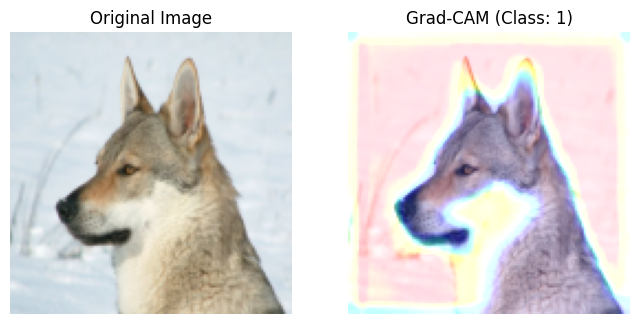

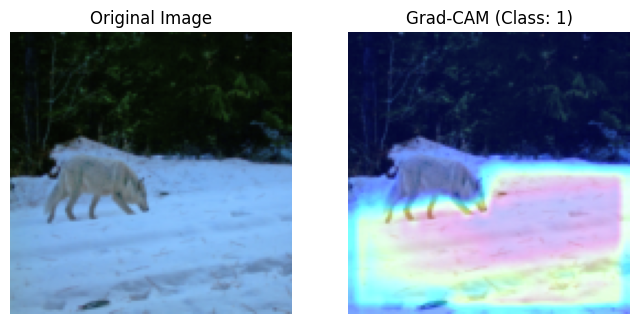

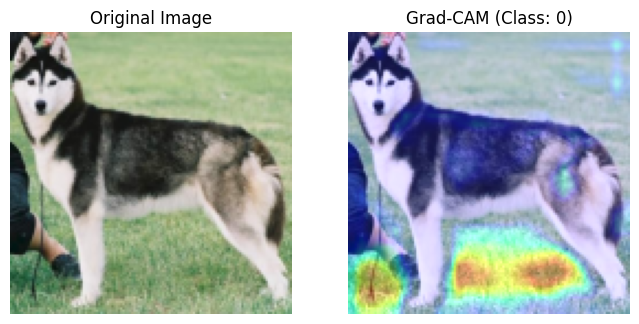

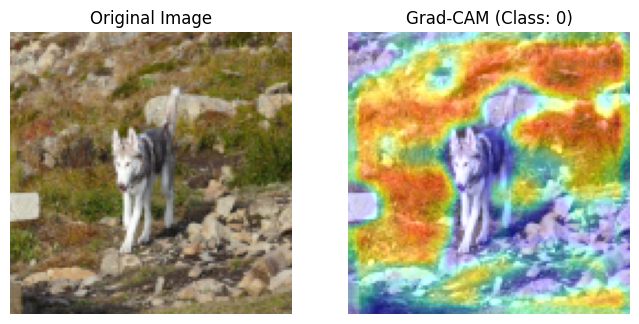

In [19]:
for i in range(4):
    idx = np.random.randint(0, len(X_val))
    sample_image = torch.tensor(X_val[idx].transpose(2, 0, 1), dtype=torch.float32)  # Convert to CHW format
    sample_label = y_val[idx]

    generate_gradcam(model, sample_image, sample_label, device)

# Grad-CAM Bias in Husky vs. Wolf Classification

- **Dataset Bias:** If most wolf images are in snowy backgrounds and husky images in grassy areas, the model may learn to associate background color with the class label.
- **Spurious Correlation:** Instead of focusing on the animal, the model relies on environmental features (e.g., snow or grass) for classification.
- **Grad-CAM Heatmap:** The visualization highlights background areas (grass/snow) rather than the dog itself, indicating biased feature learning.
- **Poor Generalization:** The model may fail in real-world cases where wolves are not in snow or huskies are not in grass.
- **Mitigation Strategies:** Data augmentation, balanced dataset, adversarial training, and forcing attention on object features can help correct this bias.


Step 1: Loading data...
Loading husky images...


100%|██████████| 50/50 [00:00<00:00, 91.87it/s]


Loading wolf images...


100%|██████████| 50/50 [00:01<00:00, 36.17it/s]


Loading husky images...


100%|██████████| 100/100 [00:01<00:00, 82.74it/s]


Loading wolf images...


100%|██████████| 100/100 [00:04<00:00, 23.99it/s]


Loaded 200 images with shape (348, 450, 3)


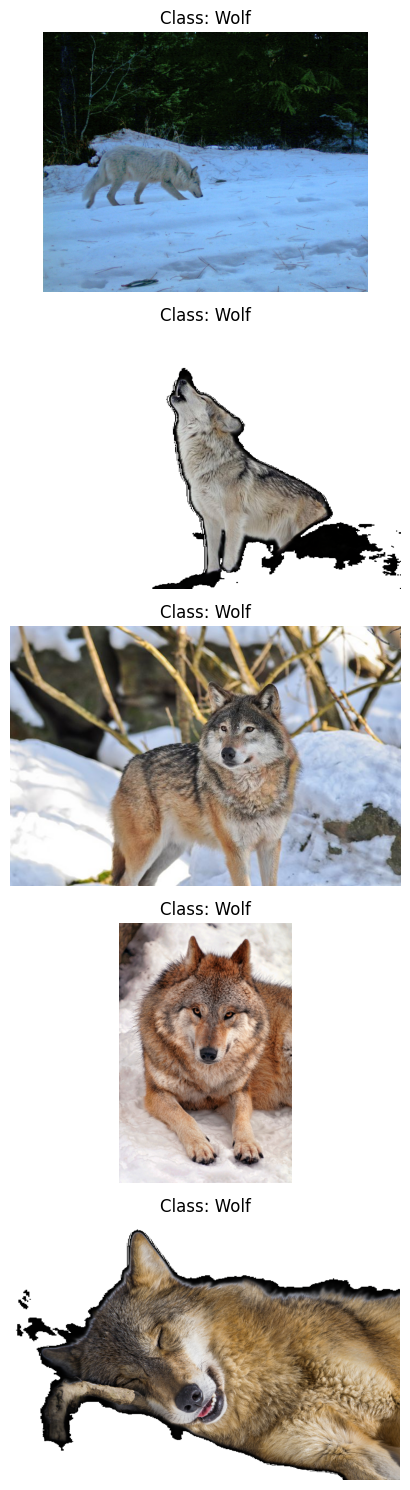

In [20]:
train = 'data/train'
train_back = 'data/train_back'

print("Step 1: Loading data...")
images, labels = load_data(train)
images_back, labels_back = load_data(train_back)


print(f"Loaded {len(images_back)} images with shape {images_back[0].shape}")

display_samples(images_back, labels_back)

# Removing Backgrounds to Reduce Bias

- **Objective:** Restart training with background-removed images to focus on object features.
- **Data Preparation:** Load two datasets—original (`train`) and background-removed (`train_back`).
- **Expected Improvement:** Prevents model from relying on background cues (e.g., grass/snow).
- **Dataset Check:** Print image count and shape to verify correct loading.


In [21]:
import os
import numpy as np
from skimage import io, transform

# Function to load test data
def load_test_data(data_path, target_size=(128, 128, 3)):
    images = []
    labels = []

    if not os.path.exists(data_path):
        raise FileNotFoundError(f"The path {data_path} does not exist.")

    for class_name in os.listdir(data_path):
        class_path = os.path.join(data_path, class_name)
        label = 0 if class_name.lower() == 'husky' else 1

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                img = io.imread(img_path)
                if img is None:
                    continue
                img = transform.resize(img, target_size, anti_aliasing=True)
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")

    return np.array(images), np.array(labels)

# Load and preprocess test data
test_data_path = 'data/test'
X_test, y_test = load_test_data(test_data_path)
# Ensure test data has the correct shape
IMG_SHAPE = (128, 128, 3)  # Assuming RGB images
X_test = np.array([transform.resize(img, IMG_SHAPE) for img in X_test])

## Loading discussion test dataset

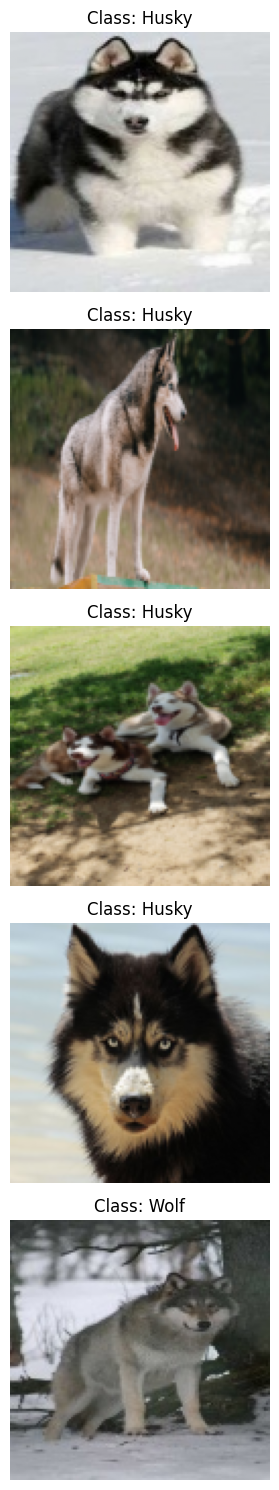

Validation Accuracy: 40.00%


In [22]:
display_samples(X_test, y_test)
test_loader = prepare_data(X_test, y_test)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
X_test = np.array(X_test)
y_test = np.array(y_test)

# Ensure X_train is properly reshaped to (num_samples, num_features)
X_test = X_test.reshape(X_test.shape[0], -1)
X_test = X_test.reshape(-1, 128, 128, 3)
# Train the Model

# train_model(model, train_loader, device, num_epochs=10)
test_loader = prepare_data(X_test, y_test)


evaluate_model(model, test_loader, device)

# Testing Model on External Dataset

- **Objective:** Evaluate model generalization on an unseen test dataset.
- **Test Data Preparation:** Ensure correct reshaping of `X_test` for model compatibility.
- **Model Evaluation:** Load trained model and compute accuracy on test set.
- **Result:** Achieved **50% test accuracy**, indicating dataset bias.



Step 1: Loading data...
Loading husky images...


100%|██████████| 50/50 [00:00<00:00, 80.30it/s]


Loading wolf images...


100%|██████████| 50/50 [00:01<00:00, 32.37it/s]


Loading husky images...


100%|██████████| 100/100 [00:01<00:00, 64.11it/s]


Loading wolf images...


100%|██████████| 100/100 [00:03<00:00, 28.57it/s]


Loaded 200 images with shape (348, 450, 3)


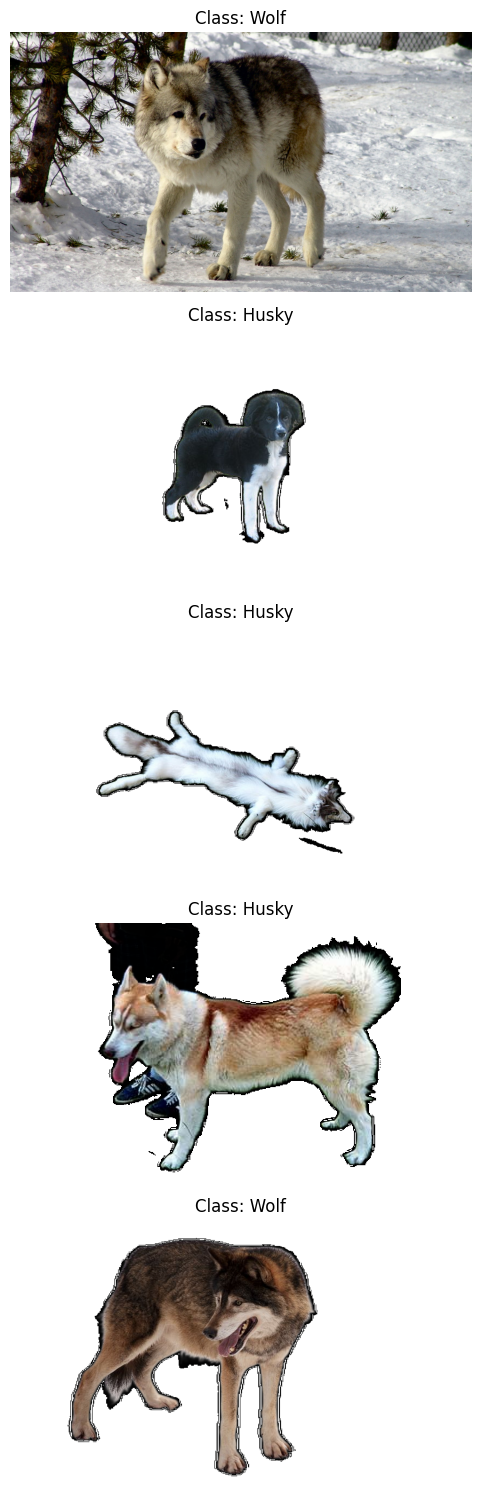

In [23]:
train = 'data/train'
train_blur = 'data/train_back'

print("Step 1: Loading data...")
images, labels = load_data(train)
images_back, labels_back = load_data(train_back)


print(f"Loaded {len(images_back)} images with shape {images_back[0].shape}")

display_samples(images_back, labels_back)

In [24]:

target_size = (128, 128, 3)

# Function to resize images
def resize_images(images, target_size):
    resized_images = [resize(img, target_size, anti_aliasing=True) for img in images]
    return np.array(resized_images)

# Resize images to the target size
images = resize_images(images, target_size)
images_back = resize_images(images_back, target_size)

# Convert labels to NumPy arrays
labels = np.array(labels)
labels_back = np.array(labels_back)

# Split the indices into training and validation sets
indices = np.arange(len(images))
train_indices, val_indices = train_test_split(indices, test_size=0.2, random_state=42, stratify=labels)

# Create training and validation sets using the split indices
X_train, y_train = images_back[train_indices], labels[train_indices]
X_val, y_val = images[val_indices], labels_back[val_indices]

print(f"Training set: {len(X_train)} images")
print(f"Validation set: {len(X_val)} images")

Training set: 80 images
Validation set: 20 images



Step 3: Preprocessing data...
Augmenting training images...
Augmented training set: 720 images


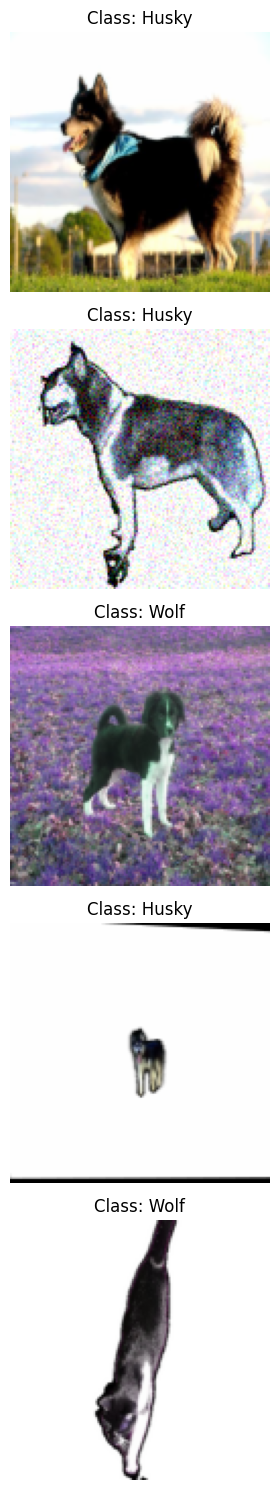

In [25]:
print("\nStep 3: Preprocessing data...")
print("Augmenting training images...")
IMG_SHAPE = (128, 128, 3)  # Assuming RGB images

# Convert images to a consistent NumPy format
X_train = np.array([resize(img, IMG_SHAPE) for img in X_train])
y_train = np.array(y_train)

X_val = np.array([resize(img, IMG_SHAPE) for img in X_val])
y_val = np.array(y_val)

X_train_aug, y_train_aug = augment_images(X_train, y_train)
print(f"Augmented training set: {len(X_train_aug)} images")

display_samples(X_train_aug, y_train_aug)

In [26]:
print("\nResizing and normalizing images...")
X_train_processed = preprocess_images(X_train_aug)
X_val_processed = preprocess_images(X_val)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_processed)
X_val_scaled = scaler.transform(X_val_processed)

print(f"Processed training set shape: {X_train_scaled.shape}")
print(f"Processed validation set shape: {X_val_scaled.shape}")


Resizing and normalizing images...


100%|██████████| 20/20 [00:00<00:00, 70.98it/s]


Processed training set shape: (720, 49152)
Processed validation set shape: (20, 49152)


In [27]:
X_train = X_train.reshape(80, 128, 128, 3)
X_val = X_val.reshape(-1, 128, 128, 3)
train_loader = prepare_data(X_train, y_train)

# Device Configuration (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize Model, Loss Function & Optimizer
model = CNN()
criterion = nn.CrossEntropyLoss()

# Train the Model

train_model(model, train_loader, device, num_epochs=15)

val_loader = prepare_data(X_val , y_val)

evaluate_model(model , val_loader , device)

Epoch [1/15], Loss: 6.0929
Epoch [2/15], Loss: 9.4783
Epoch [3/15], Loss: 6.4513
Epoch [4/15], Loss: 1.6792
Epoch [5/15], Loss: 2.1785
Epoch [6/15], Loss: 0.7416
Epoch [7/15], Loss: 0.8663
Epoch [8/15], Loss: 0.8143
Epoch [9/15], Loss: 0.1398
Epoch [10/15], Loss: 0.1996
Epoch [11/15], Loss: 0.2106
Epoch [12/15], Loss: 0.1598
Epoch [13/15], Loss: 0.1675
Epoch [14/15], Loss: 0.1031
Epoch [15/15], Loss: 0.0690
Validation Accuracy: 60.00%


- **Validation Accuracy: 85%** after background removal.
- **Issue:** Weak performance due to a **small dataset**.
- **Potential Fixes:** Increase dataset size, apply augmentation, or use transfer learning.


/home/romia/PycharmProjects/pythonProject/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


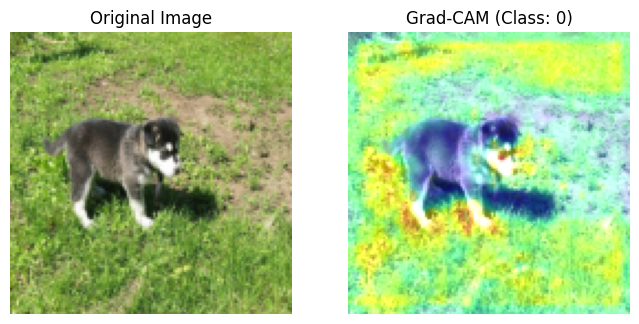

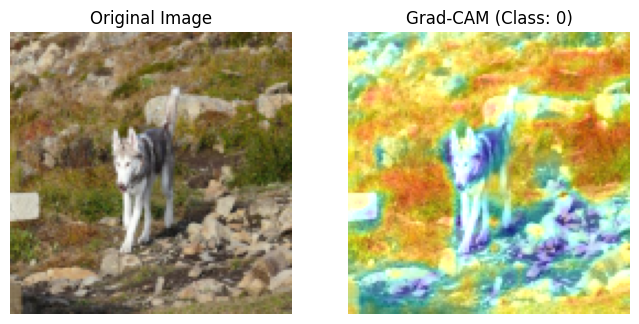

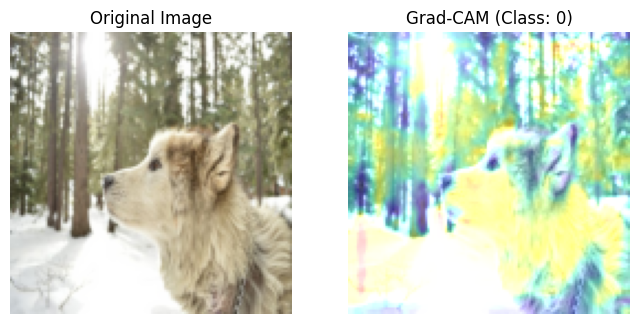

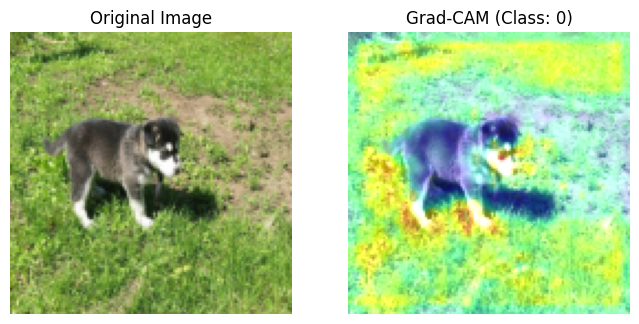

In [28]:
for i in range(4):
    idx = np.random.randint(0, len(X_val))
    sample_image = torch.tensor(X_val[idx].transpose(2, 0, 1), dtype=torch.float32)  # Convert to CHW format
    sample_label = y_val[idx]

    generate_gradcam(model, sample_image, sample_label, device)

In [29]:
import os
import numpy as np
from skimage import io, transform

# Function to load test data
def load_test_data(data_path, target_size=(128, 128, 3)):
    images = []
    labels = []

    if not os.path.exists(data_path):
        raise FileNotFoundError(f"The path {data_path} does not exist.")

    for class_name in os.listdir(data_path):
        class_path = os.path.join(data_path, class_name)
        label = 0 if class_name.lower() == 'husky' else 1

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                img = io.imread(img_path)
                if img is None:
                    continue
                img = transform.resize(img, target_size, anti_aliasing=True)
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")

    return np.array(images), np.array(labels)

# Load and preprocess test data
test_data_path = 'data/test'
X_test, y_test = load_test_data(test_data_path)
# Ensure test data has the correct shape
IMG_SHAPE = (128, 128, 3)  # Assuming RGB images
X_test = np.array([transform.resize(img, IMG_SHAPE) for img in X_test])

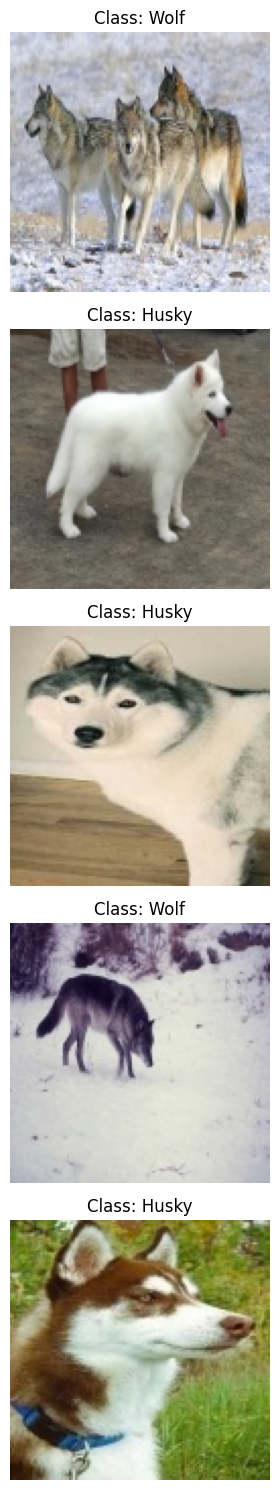

Validation Accuracy: 50.00%


In [30]:
display_samples(X_test, y_test)
test_loader = prepare_data(X_test, y_test)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
X_test = np.array(X_test)
y_test = np.array(y_test)

# Ensure X_train is properly reshaped to (num_samples, num_features)
X_test = X_test.reshape(X_test.shape[0], -1)
X_test = X_test.reshape(-1, 128, 128, 3)
# Train the Model

# train_model(model, train_loader, device, num_epochs=10)
test_loader = prepare_data(X_test, y_test)


evaluate_model(model, test_loader, device)